# ViT displacement model → motion validation

Loads the 12 static `images/capture_x_y_z.png` frames (ground-truth `x, y, z` position in mm baked
into the filename), runs every pair through the trained diff-pred ViT (`checkpoints/diff_pred_epoch_0040.pt`,
same architecture as `diff_pred.ipynb`) in a single batched forward pass, plots per-axis GT-vs-pred
error (mirroring `peraxis_hdr` in `diff_pred.ipynb`), and finally lets you pick a pair and visually
validate a predicted (or ground-truth) displacement by warping frame 1 onto frame 2 with
`cv2.warpAffine`, as in `validate_encoder.py`.

In [9]:
import re
import itertools
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from transformers import ViTConfig, ViTModel

REPO_ROOT  = Path.cwd().parent if Path.cwd().name == 'views_and_calibration' else Path.cwd()
IMG_SIZE   = 224
PATCH_SIZE = 16
EMB_DIM    = 192
BLUR_SIGMA = 2.0     # must match diff_pred.ipynb training
CKPT_PATH  = REPO_ROOT / 'checkpoints' / 'diff_pred_epoch_0040.pt'
IMAGES_DIR = REPO_ROOT / 'images'

AXIS_NAMES = ['x', 'y', 'cx', 'cy', 'area']
AXIS_UNITS = ['mm', 'mm', 'px', 'px', 'px²']

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Device: {device}')

Device: mps


### Load the 12 images + their ground-truth (x, y, z) positions from the filenames

In [2]:
FNAME_RE = re.compile(r'capture_([-\d.eE]+)_([-\d.eE]+)_([-\d.eE]+)\.png$')

paths = sorted(IMAGES_DIR.glob('capture_*.png'))
print(f'Found {len(paths)} images')

frames_bgr = []
xyz = []
for p in paths:
    m = FNAME_RE.search(p.name)
    if not m:
        raise ValueError(f'Could not parse x, y, z from filename: {p.name}')
    xyz.append([float(m.group(1)), float(m.group(2)), float(m.group(3))])
    img = cv2.imread(str(p))
    if img is None:
        raise FileNotFoundError(p)
    frames_bgr.append(img)

xyz = np.array(xyz, dtype=np.float32)   # (12, 3) mm
print('xyz (mm):')
for p, v in zip(paths, xyz):
    print(f'  {p.name}: {v}')

Found 12 images
xyz (mm):
  capture_6.0875596_4.4798457_5.122473.png: [6.0875597 4.4798455 5.122473 ]
  capture_6.0875596_4.834192_5.122473.png: [6.0875597 4.834192  5.122473 ]
  capture_6.310346_4.783894_5.046777.png: [6.310346 4.783894 5.046777]
  capture_6.5231245_4.758067_5.122473.png: [6.5231247 4.758067  5.122473 ]
  capture_6.6036383_4.950496_5.122473.png: [6.603638 4.950496 5.122473]
  capture_6.6036383_4.9990017_5.122473.png: [6.603638  4.9990015 5.122473 ]
  capture_6.743484_4.9990017_5.122473.png: [6.743484  4.9990015 5.122473 ]
  capture_6.843458_4.79726_4.9718344.png: [6.843458 4.79726  4.971834]
  capture_6.843458_4.79726_4.9868676.png: [6.843458  4.79726   4.9868674]
  capture_6.843458_4.79726_4.9999506.png: [6.843458  4.79726   4.9999504]
  capture_6.8700566_4.758067_5.122473.png: [6.8700566 4.758067  5.122473 ]
  capture_6.8898707_4.492427_5.122473.png: [6.8898706 4.492427  5.122473 ]


### Build the model (same architecture as `diff_pred.ipynb`) and load the checkpoint

In [3]:
class DisplacementHead(nn.Module):
    """CLS token -> small MLP -> (5,): [Δx, Δy, Δcx, Δcy, Δarea]."""

    def __init__(self, emb_dim=EMB_DIM, target_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 256),
            nn.SiLU(),
            nn.Linear(256, target_dim),
        )

    def forward(self, emb):
        return self.net(emb)


def make_gaussian_kernel(sigma: float, device: str):
    """(1, 1, k, k) normalized 2D gaussian kernel, k = 2*round(3*sigma)+1."""
    if sigma <= 0:
        return None
    radius = max(1, int(round(3 * sigma)))
    coords = torch.arange(-radius, radius + 1, dtype=torch.float32, device=device)
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = torch.outer(g, g)
    kernel_2d = kernel_2d / kernel_2d.sum()
    return kernel_2d.view(1, 1, kernel_2d.shape[0], kernel_2d.shape[1])


def gaussian_blur(x: torch.Tensor, kernel: torch.Tensor | None) -> torch.Tensor:
    """(B, C, H, W) -> (B, C, H, W), blurred per-channel (depthwise conv, same padding)."""
    if kernel is None:
        return x
    c = x.shape[1]
    k = kernel.repeat(c, 1, 1, 1).to(dtype=x.dtype, device=x.device)
    pad = k.shape[-1] // 2
    return torch.nn.functional.conv2d(x, k, padding=pad, groups=c)


vit_cfg = ViTConfig(
    num_channels=3, image_size=IMG_SIZE, patch_size=PATCH_SIZE,
    hidden_size=EMB_DIM, num_hidden_layers=6,
    num_attention_heads=3, intermediate_size=768,
)
vit  = ViTModel(vit_cfg, add_pooling_layer=False).to(device).eval()
head = DisplacementHead(emb_dim=EMB_DIM, target_dim=5).to(device).eval()

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
vit.load_state_dict(ckpt['vit'])
head.load_state_dict(ckpt['head'])
delta_mean = ckpt['delta_mean'].to(device)
delta_std  = ckpt['delta_std'].to(device)
print(f'Loaded {CKPT_PATH.name} (epoch {ckpt.get("epoch", "?")})')

blur_kernel = make_gaussian_kernel(BLUR_SIGMA, device)

Loaded diff_pred_epoch_0040.pt (epoch 40)


### Run every pair through the ViT in a single batched forward pass

In [4]:
# Resize + blur each of the 12 frames once (blur is linear, so blur(f_j) - blur(f_i)
# can be built directly from the 12 precomputed blurred frames for every pair).
resized_float = []
for bgr in frames_bgr:
    rgb = cv2.resize(bgr[:, :, ::-1], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    t = torch.from_numpy(rgb.copy()).permute(2, 0, 1).float().div_(255.0)
    resized_float.append(t)
resized_float = torch.stack(resized_float).to(device)   # (12, 3, 224, 224)

with torch.no_grad():
    blurred = gaussian_blur(resized_float, blur_kernel)   # (12, 3, 224, 224)

pairs = list(itertools.combinations(range(len(paths)), 2))   # all (i, j), i < j
print(f'{len(pairs)} pairs from {len(paths)} images')

idx_i = torch.tensor([p[0] for p in pairs], device=device)
idx_j = torch.tensor([p[1] for p in pairs], device=device)
diff_batch = blurred[idx_j] - blurred[idx_i]   # (n_pairs, 3, 224, 224)

with torch.no_grad():
    hidden     = vit(diff_batch, interpolate_pos_encoding=False).last_hidden_state   # (n_pairs, 1+N, EMB_DIM)
    cls_tokens = hidden[:, 0]                                                          # (n_pairs, EMB_DIM)
    pred_norm  = head(cls_tokens)                                                      # (n_pairs, 5)
    pred_raw   = (pred_norm * delta_std + delta_mean).cpu().numpy()                    # (n_pairs, 5)

gt_xy = xyz[idx_j.cpu().numpy(), :2] - xyz[idx_i.cpu().numpy(), :2]   # (n_pairs, 2) mm ground truth
print(f'pred_raw shape: {pred_raw.shape}   gt_xy shape: {gt_xy.shape}')

66 pairs from 12 images
pred_raw shape: (66, 5)   gt_xy shape: (66, 2)


### Per-axis error distribution

Per-axis MAE — images/ pairs (Δx, Δy only; Δcx/Δcy/Δarea have no ground truth here):
  x: MAE=0.112 mm   RMSE=0.137 mm   (n=66)
  y: MAE=0.113 mm   RMSE=0.156 mm   (n=66)


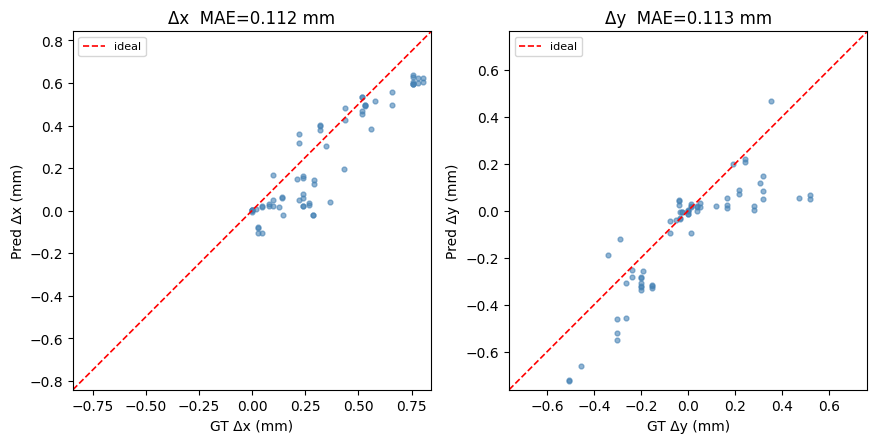

In [5]:
# Only Δx and Δy have ground truth available here (baked into the filenames); Δcx, Δcy, Δarea
# have no ground truth for this static image set (no Newton-ring annotations), so only the first
# two axes are plotted against GT — mirroring the `peraxis_hdr` cell in diff_pred.ipynb.
errors = pred_raw[:, :2] - gt_xy

print('Per-axis MAE — images/ pairs (Δx, Δy only; Δcx/Δcy/Δarea have no ground truth here):')
for i, name in enumerate(['x', 'y']):
    mae  = np.abs(errors[:, i]).mean()
    rmse = np.sqrt((errors[:, i] ** 2).mean())
    print(f'  {name}: MAE={mae:.3f} mm   RMSE={rmse:.3f} mm   (n={len(errors)})')

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for i, name in enumerate(['x', 'y']):
    ax  = axes[i]
    gt  = gt_xy[:, i]
    pr  = pred_raw[:, i]
    lim = max(np.abs(gt).max(), np.abs(pr).max()) * 1.05
    ax.scatter(gt, pr, s=12, alpha=0.6, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.2, label='ideal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'GT Δ{name} (mm)'); ax.set_ylabel(f'Pred Δ{name} (mm)')
    ax.set_title(f'Δ{name}  MAE={np.abs(errors[:, i]).mean():.3f} mm')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Affine-transform overlay validation

Pick a pair of frames, take either the **predicted** or **ground-truth** (Δx, Δy) displacement,
convert mm → px with `PX_PER_MM`, warp frame 1 by that displacement (as in `validate_encoder.py`),
and inspect: `frame 1 | frame 2 | warped frame 1 | diff magnitude (untransformed) | overlay (warped frame 1 on frame 2)`.

Pair: capture_6.0875596_4.834192_5.122473.png  ->  capture_6.8898707_4.492427_5.122473.png
ground-truth Δ(x, y) = [ 0.80231094 -0.34176493] mm 
predicted Δ(x, y) = [ 0.6029998 -0.1897989] mm 
Using ground-truth


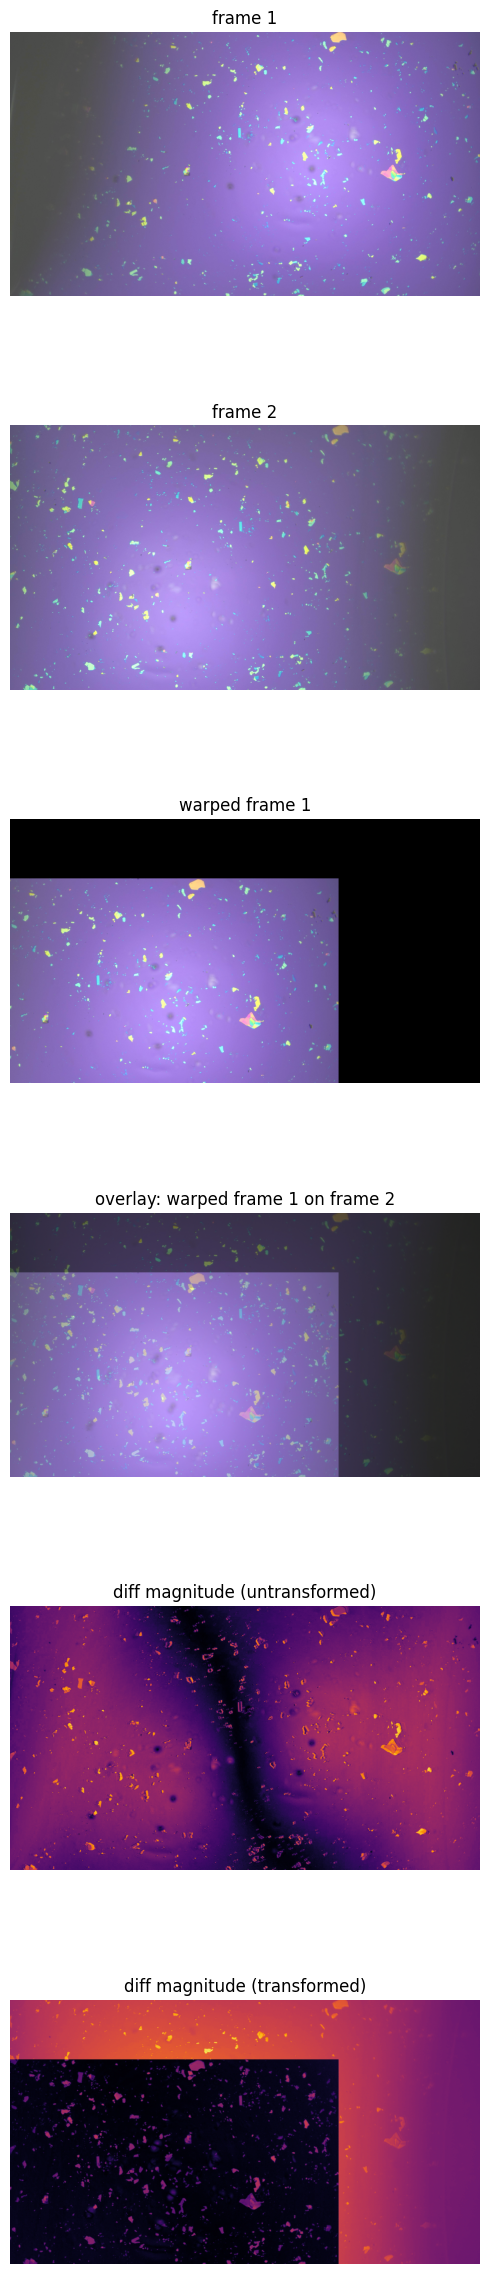

In [71]:
PAIR_IDX = 20         # index into `pairs` / `pred_raw` / `gt_xy`
USE_GT   = True      # True -> use ground-truth (Δx, Δy); False -> use the ViT's prediction
PX_PER_MM_X  = 1440.0  # calibration, same default as validate_encoder.py
PX_PER_MM_Y  = 1440.0  # calibration, same default as validate_encoder.py

i, j = pairs[PAIR_IDX]
frame1 = frames_bgr[i][:, :, ::-1]   # RGB
frame2 = frames_bgr[j][:, :, ::-1]   # RGB

delta_mm = gt_xy[PAIR_IDX] if USE_GT else pred_raw[PAIR_IDX, :2]
delta_px = delta_mm.copy()
delta_px[0] *= PX_PER_MM_X
delta_px[1] *= PX_PER_MM_Y

print(f'Pair: {paths[i].name}  ->  {paths[j].name}')
print(f'ground-truth Δ(x, y) = {gt_xy[PAIR_IDX]} mm ')
print(f'predicted Δ(x, y) = {pred_raw[PAIR_IDX, :2]} mm ')
print(f'Using {"ground-truth" if USE_GT else "predicted"}')

M = np.array([[1, 0, -delta_px[0]],
              [0, 1, -delta_px[1]]], dtype=np.float32)   # image y grows downward
h, w = frame1.shape[:2]
warped = cv2.warpAffine(frame1, M, (w, h))

diff_mag = np.linalg.norm(frame2.astype(np.float32) - frame1.astype(np.float32), axis=-1)
diff_mag_warped = np.linalg.norm(frame2.astype(np.float32) - warped.astype(np.float32), axis=-1)

overlay = cv2.addWeighted(frame2, 0.5, warped, 0.5, 0.0)

fig, axes = plt.subplots(6, 1, figsize=(5, 24))
axes[0].imshow(frame1);   axes[0].set_title('frame 1');                 axes[0].axis('off')
axes[1].imshow(frame2);   axes[1].set_title('frame 2');                 axes[1].axis('off')
axes[2].imshow(warped);   axes[2].set_title('warped frame 1');          axes[2].axis('off')
axes[3].imshow(overlay);  axes[3].set_title('overlay: warped frame 1 on frame 2'); axes[3].axis('off')
axes[4].imshow(diff_mag, cmap='inferno'); axes[4].set_title('diff magnitude (untransformed)'); axes[4].axis('off')
axes[5].imshow(diff_mag_warped, cmap='inferno'); axes[5].set_title('diff magnitude (transformed)'); axes[5].axis('off')

plt.tight_layout()
plt.show()